Task 1

In [1]:
import pandas as pd

df2 = pd.read_csv('../data/q2_customers.csv')

print("Shape of dataset:", df2.shape)
print("\nFirst five rows:")
print(df2.head())

print("\nDescriptive statistics:")
print(df2.describe())

Shape of dataset: (500, 6)

First five rows:
   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  

Descriptive statistics:
             age   annual_spend  visits_per_month  basket_size  \
count  500.00000     500.000000        500.000000   500.000000   
mean    40.45200   48856.948000          8.414000  2682.286000   
std     14.42664   32856.795353          5.324595  2274.957339   
min     18.00000 

All features in the dataset are numerical but exist on very different scales. For example, annual_spend has values in the tens of thousands, while features like visits_per_month and num_categories_purchased have much smaller ranges.

Since K-Means clustering is distance-based, features with larger magnitudes would dominate the clustering process if left unscaled. Therefore, feature scaling is essential to ensure that all variables contribute equally to the distance calculations.

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df2)

# Convert back to DataFrame for easier use
df_scaled = pd.DataFrame(scaled_data, columns=df2.columns)

df_scaled.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


Task 2

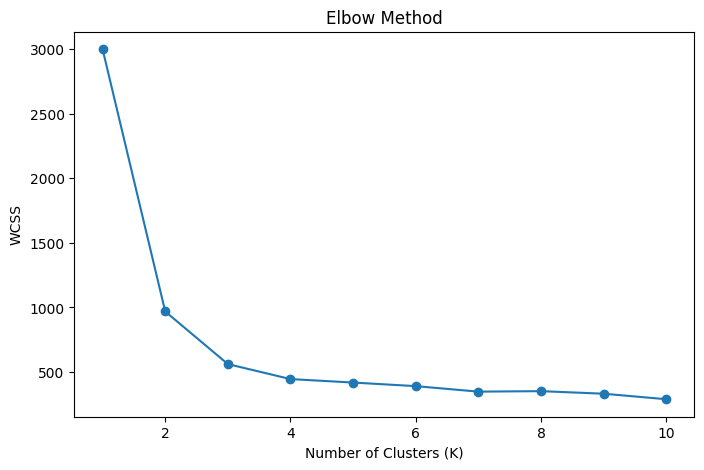

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []  # Within-Cluster Sum of Squares

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

The Elbow Method was used to determine the optimal number of clusters. The plot shows a sharp decrease in WCSS from K = 1 to K = 3, after which the rate of decrease slows significantly.

This indicates that adding more clusters beyond K = 3 does not provide substantial improvement in clustering performance. Therefore, K = 3 is chosen as the optimal number of clusters.

Task 3

In [4]:
kmeans = KMeans(n_clusters=3, random_state=42)
df_scaled['cluster'] = kmeans.fit_predict(df_scaled)

df_scaled.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952,2
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685,0
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139,2
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230,0
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776,0


In [5]:
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=df2.columns)
centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-1.094595,-1.036122,1.114284,-0.934278,-0.813494,-1.045346
1,1.132214,1.235574,-1.106680,1.253260,1.125725,1.172991
2,-0.004449,-0.168055,-0.041370,-0.290670,-0.287579,-0.095968


The clustering results reveal three distinct customer segments based on their purchasing behaviour.

Cluster 0 represents younger customers who visit frequently but have low spending levels and purchase fewer product categories. These can be described as frequent low-spending customers.

Cluster 1 represents older customers with high annual spending and larger basket sizes, but who visit less frequently. They also purchase a wider range of product categories. This group can be classified as high-value occasional shoppers.

Cluster 2 represents customers with average values across most features, indicating moderate spending, visit frequency, and purchasing behaviour. These can be considered regular average customers.

These clusters provide meaningful business insights, allowing the company to target different customer segments with tailored marketing strategies.

Task 4

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_scaled.drop('cluster', axis=1))

df_pca = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])
df_pca['cluster'] = df_scaled['cluster']

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.83560354 0.05568764]


In [7]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df2.columns
)

print("PCA Feature Loadings:")
print(loadings)

PCA Feature Loadings:
                               PC1       PC2
age                       0.411569 -0.259432
annual_spend              0.421540 -0.033270
visits_per_month         -0.410399  0.208318
basket_size               0.412012 -0.195402
days_since_last_visit     0.378582  0.911194
num_categories_purchased  0.414017 -0.140479


The PCA results show that the first principal component (PC1) explains approximately 83.56% of the total variance in the data, while the second principal component (PC2) explains around 5.57%.

This indicates that most of the variability in the dataset is captured by PC1, suggesting that the data is largely influenced by a single dominant pattern. Together, PC1 and PC2 explain nearly 89% of the variance, which means that reducing the data to two dimensions retains most of the important information.

Therefore, the 2D PCA representation is sufficient for visualising the clusters without significant loss of information.

Task 5

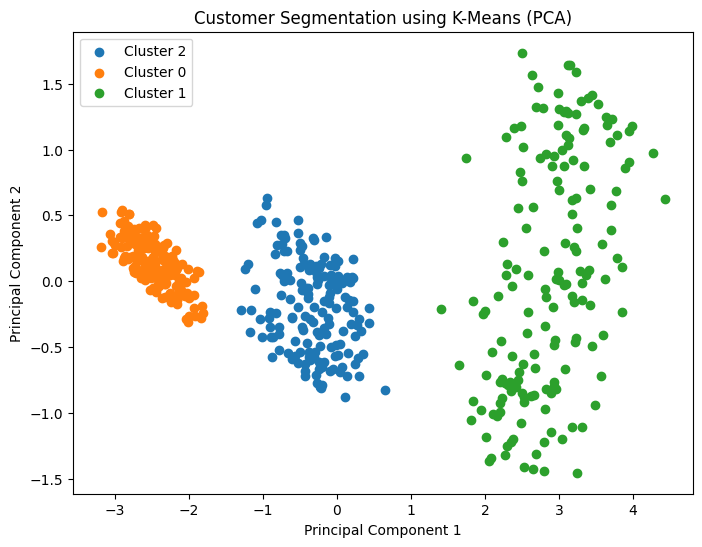

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for cluster in df_pca['cluster'].unique():
    subset = df_pca[df_pca['cluster'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}')

plt.title('Customer Segmentation using K-Means (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

The scatter plot shows clear separation between the three clusters, primarily along the first principal component (PC1). This indicates that the clustering has effectively grouped customers based on their behavioural patterns.

Cluster 1 appears more distinct, while clusters 0 and 2 show some overlap, suggesting that certain customer behaviours are more similar. Overall, the clustering structure is reasonably well-defined and supports the segmentation results obtained earlier.